# Recall, precision, and the price of a filter

*BM25, vector, hybrid, and filtered-hybrid over the same 40 queries — scored with `trec_eval`.*

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/omnifroodle/couchbase_notebooks/blob/main/notebooks/retrieval/02_which_parts_helped.ipynb)
[![Open in GitHub Codespaces](https://img.shields.io/badge/Open%20in%20Codespaces-2f363d?logo=github&logoColor=white)](https://codespaces.new/omnifroodle/couchbase_notebooks?quickstart=1)

**Claim.** Four retrieval strategies, scored properly, do not agree on a winner — and an aggregate score hides more than it shows.
**Result.** BM25 trails on ordering (nDCG@10 ~0.71 against ~0.78); vector and the hybrids sit so close on that column that which one leads changes between runs; the hybrids lead recall@50; and a department filter that barely moves the average changes recall for 8–10 of the 40 queries.
**Requires.** couchbase · local-embeddings
**Read** ~8 min · **Run** ~6 min · **Cost** $0.00 — no LLM calls

[`retrieval/01`](01_building_hybrid_search.ipynb) built four ways to search the same
catalogue — lexical, vector, hybrid, and hybrid with a filter — and ended by showing that you
cannot tell them apart by reading results. All four look fine.

Reading can't tell them apart; measuring can. This notebook scores all four against human
judgements, and finds that the answer to *which is best* depends on what you measure, and
that some of the gaps are smaller than the noise.

Wayfair's [WANDS](https://github.com/wayfair/WANDS) dataset makes that answerable. It ships
480 real search queries and 233,000 human relevance judgements — every one a person deciding
whether a product was `Exact`, `Partial` or `Irrelevant` for a query. That is ground truth,
and it lets us score four retrieval strategies against each other rather than squinting at
result lists.

**What this notebook does**

1. Loads a 40-query benchmark with complete judgements, small enough to index in a minute.
2. Puts the products in Couchbase with one Search index carrying text, a vector, and
   keyword fields for filtering.
3. Runs four strategies over the same queries: BM25, vector, hybrid, and hybrid with a
   department filter.
4. Scores them with `trec_eval` — the reference implementation the IR literature reports
   against — and shows where the metrics disagree.

No LLM is involved and nothing costs money. The embedding model runs on your machine.

In [ ]:
# Setup: load the helpers, install anything missing, check what this notebook needs.
import os
import pathlib
import subprocess
import sys

# Cloned on Colab, where there is no local checkout. Override to test a fork.
REPO_URL = os.environ.get("CBNB_REPO_URL", "https://github.com/omnifroodle/couchbase_notebooks")

try:
    import cbnb
except ModuleNotFoundError:
    here = pathlib.Path.cwd()
    root = next((p for p in [here, *here.parents] if (p / "cbnb" / "__init__.py").exists()), None)
    if root is None:
        # Colab: clone the repo so the committed datasets come with it.
        subprocess.check_call(["git", "clone", "--depth", "1", "--quiet", REPO_URL, "cbnb-repo"])
        root = pathlib.Path("cbnb-repo").resolve()
    sys.path.insert(0, str(root))
    import cbnb

settings = cbnb.bootstrap(requires=["couchbase", "local-embeddings"], extras=["metrics", "plots"])

## 1. A benchmark small enough to run

WANDS judges 480 queries against all 43,000 products. Indexing that for a demo would be slow
and almost entirely wasted: a query is only ever scored against the products a human actually
looked at for it.

So this is a **pool** — 40 queries, plus every product judged for one of them. It ships with
the repo, so nothing downloads.

One consequence has to be stated plainly, because it is the most common way an evaluation
lies: **recall here is measured against the pool, not against the catalogue.** Comparing two
systems over the same pool is sound. Reading "recall@50 = 0.6" as *"we found 60% of the
matching products Wayfair sells"* is not — a product nobody judged cannot be found, and does
not count against you.

In [2]:
# Load the WANDS evaluation set: queries, products and human judgements.
from cbnb.datasets import load_wands_eval_set

evalset = load_wands_eval_set()
print(evalset.summary())

evalset.queries[["query_id", "query", "query_class"]].head(8)

40 queries, 6,482 products, 6,986 judgements (2,506 Exact)


,query_id,query,query_class
0,10,king poster bed,Beds
1,12,large spoon and fork wall decor,Wall Décor
2,20,foutains with brick look,Wallpaper
3,25,sunflower,Wall Art
4,45,70s inspired furniture,Wall Art
5,59,broadway lever,Door Levers
6,63,monthly calendar,Memo Boards
7,68,nautical platters,Serving Dishes & Platters


Each judgement is one of three grades, and the balance matters: `Partial` is the largest
group — more numerous than `Exact` — which is why a metric that only counts exact hits would
throw away a large part of the signal a human gave us.

In [3]:
# Count the human judgements by label.
evalset.labels.label.value_counts().to_frame("judgements")

,judgements
label,
Partial,3342
Exact,2506
Irrelevant,1138


## 2. One index, three kinds of field

A single Couchbase Search index carries everything the four strategies need:

- **`text`** — the product name and class, analysed for BM25 matching.
- **`embedding`** — a 384-dimension vector for nearest-neighbour search.
- **`department`** and **`category_path`** — indexed with the keyword analyser, so they match
  verbatim and can be used as filters rather than as search terms.

Both the lexical and the vector side read the *same* `text` field, so neither strategy gets
an advantage from seeing more of the product than the other.

In [4]:
# Build the text each product is indexed by.
import pandas as pd

pd.set_option("display.max_colwidth", None)   # show whole product names, not "roun..."

BUCKET = settings.cb_bucket
SCOPE = "hybrid_retrieval"
COLLECTION = "products"
INDEX = "products_hybrid"

products = evalset.products.copy()
products["category_hierarchy"] = products.category_hierarchy.fillna("")
products["department"] = products.category_hierarchy.str.split(" / ").str[0]
# One text field, read by both the lexical and the vector side.
products["text"] = (products.product_name.fillna("") + " " + products.product_class.fillna("")).str.strip()

print(f"{len(products):,} products, {products.department.nunique()} departments")
products[["product_id", "text", "department"]].head(4)

6,482 products, 33 departments


,product_id,text,department
0,4,baldwin prestige alcott passage knob with round rosette Door Knobs,Home Improvement
1,13,king tufted low profile standard bed Beds,Furniture
2,30,lugent 70.87 '' h x 70.87 '' w x 11.8 '' d steel etagere bookcase Bookcases,Furniture
3,33,tatianna 2 piece pine solid wood floating shelf Bookcases|Wall Mounted Shelves,Storage & Organization


In [5]:
# Embed every product with a local model.
from cbnb.embeddings import Embedder

embedder = Embedder()
vectors = embedder.encode(products.text.tolist())
print(f"{vectors.shape[0]:,} embeddings, {vectors.shape[1]} dimensions")

6,482 embeddings, 384 dimensions


In [6]:
# Store the products in Couchbase.
from cbnb.couchbase_io import connect, ensure_collection, upsert_docs

cluster = connect(settings)
collection = ensure_collection(cluster, BUCKET, SCOPE, COLLECTION)

docs = {
    str(row.product_id): {
        "type": COLLECTION,
        "product_id": int(row.product_id),
        "text": row.text,
        "product_name": row.product_name,
        "department": row.department,
        "category_path": row.category_hierarchy,
        "embedding": vector.tolist(),
    }
    for row, vector in zip(products.itertuples(index=False), vectors)
}
upsert_docs(collection, docs)

  upserted 200/6482

  upserted 400/6482

  upserted 600/6482

  upserted 800/6482

  upserted 1000/6482

...

  upserted 6000/6482

  upserted 6200/6482

  upserted 6400/6482

  upserted 6482/6482

6482

In [7]:
# Build the Search index and wait until it's ready.
from cbnb.couchbase_io import ensure_vector_index, wait_for_index

ensure_vector_index(
    cluster,
    bucket_name=BUCKET, scope_name=SCOPE, collection_name=COLLECTION,
    index_name=INDEX,
    vector_field="embedding", dims=embedder.dims,
    text_fields=["text"],                              # analysed, for BM25
    keyword_fields=["department", "category_path"],    # verbatim, for filtering
)
wait_for_index(cluster, bucket_name=BUCKET, scope_name=SCOPE, index_name=INDEX, expected=len(docs))

  indexed 6482/6482 (ready)   

  indexed 6482/6482 (ready)   

6482

## 3. Four ways to answer the same question

Each function takes a query string and returns up to `k` products, best first. That is all a
retrieval strategy is, and keeping them the same shape is what makes them comparable.

The fourth needs something the others don't: a **department to filter on**. WANDS labels each
query with a class (`"Beds"`, `"Wall Décor"`), and we map that to a department using the
catalogue — never using the judgements, which would be leaking the answer into the system
we're grading.

In [8]:
# Guess each query's department from catalogue statistics alone.
class_to_department = (
    products[products.department != ""]
    .groupby("product_class").department
    .agg(lambda s: s.value_counts().idxmax())
)
query_department = evalset.queries.set_index("query_id").query_class.map(class_to_department)

covered = query_department.notna().sum()
print(f"{covered} of {len(evalset.queries)} queries get a department this way")
query_department.head(6).to_frame("department")

38 of 40 queries get a department this way


,department
query_id,
10,Furniture
12,Décor & Pillows
20,Décor & Pillows
25,Décor & Pillows
45,Décor & Pillows
59,Home Improvement


In [9]:
# Define the four search strategies being compared.
import couchbase.search as search

from cbnb.couchbase_io import hybrid_search, text_search, vector_search

K = 50                 # deep enough for recall@50
CANDIDATES = 200       # vector candidates considered before the top k is cut

where = dict(bucket_name=BUCKET, scope_name=SCOPE, index_name=INDEX)


def bm25(query, query_id, k=K):
    """Lexical only: BM25 over the analysed text field."""
    return text_search(cluster, **where, text_query=search.MatchQuery(query, field="text"), k=k)


def vector(query, query_id, k=K):
    """Semantic only: nearest neighbours of the query embedding."""
    return vector_search(cluster, **where, vector_field="embedding",
                         query_vector=embedder.encode_one(query), k=k, num_candidates=CANDIDATES)


def hybrid(query, query_id, k=K):
    """Both halves scored in a single Search request."""
    return hybrid_search(cluster, **where, vector_field="embedding",
                         query_vector=embedder.encode_one(query),
                         text_query=search.MatchQuery(query, field="text"),
                         k=k, num_candidates=CANDIDATES)


def hybrid_filtered(query, query_id, k=K):
    """Hybrid, with the vector half restricted to one department."""
    department = query_department.get(query_id)
    prefilter = None if pd.isna(department) else search.TermQuery(department, field="department")
    return hybrid_search(cluster, **where, vector_field="embedding",
                         query_vector=embedder.encode_one(query),
                         text_query=search.MatchQuery(query, field="text"),
                         k=k, num_candidates=CANDIDATES, prefilter=prefilter)


STRATEGIES = {"bm25": bm25, "vector": vector, "hybrid": hybrid, "hybrid + department filter": hybrid_filtered}

## 4. Score them

Two decisions here are ours, and both change the numbers — so they belong in the notebook
rather than buried in a helper.

**How graded judgements become gains.** WANDS grades are `Exact` / `Partial` / `Irrelevant`.
We score them 2 / 1 / 0. Raising `Exact` to 3 would reward getting the perfect product to the
top more heavily, and every nDCG below would move.

**Which measures to report.** These three answer different questions:

| | answers | in plain terms |
| --- | --- | --- |
| **nDCG@10** | Is the first screenful well ordered? | Of the ten results you show, how good are they *and* how well sorted — with a hit at rank 1 worth more than the same hit at rank 10. 1.0 means the ten best possible products, in the best possible order. |
| **R@50** | Did the right products make it into the top 50 at all? | Of every product a human judged relevant for this query, what share did we retrieve? Order doesn't matter here, only presence. 0.40 means we found two in five. |
| **RR** | How far down is the first good hit? | 1.0 if the first result is relevant, 0.5 if the second is, 0.33 if the third. Averaged over queries, it is how quickly a user's eye lands on something useful. |

**Recall sets the ceiling; nDCG decides what happens under it.** A product that never gets
retrieved cannot be ranked, so recall bounds everything downstream. But retrieving the right
products and ordering them badly still fails the person reading the screen.

**And the reader is increasingly not a person.** When these results become the context for an
LLM — the whole of `flows/`, and the reason this notebook sits in front of it — ordering still
matters, for two reasons that have nothing to do with scrolling. A context window is finite, so
what sits at the bottom of a long list is what gets cut when you trim to fit. And models do not
read a context window evenly: material at the very start and very end carries more weight than
the middle, an effect consistent enough to have a name, *lost in the middle*. Ranking well is
how you keep the best passages out of the middle. nDCG@10 is a reasonable proxy for context
quality; R@50 is a reasonable proxy for whether a reranker has anything to work with.

The arithmetic is `ir_measures`, wrapping `pytrec_eval`, wrapping `trec_eval` — the same
implementation IR papers report against, so these numbers mean what a retrieval person
expects them to mean.

In [10]:
# Run every strategy over every query and score the results.
from cbnb.eval import Run, compare, to_qrels

qrels = to_qrels(evalset.judgements())   # Exact=2, Partial=1, Irrelevant=0

runs = []
for name, strategy in STRATEGIES.items():
    results = {}
    for row in evalset.queries.itertuples(index=False):
        hits = strategy(row.query, row.query_id)
        results[str(row.query_id)] = [(h.id, h.score) for h in hits]
    runs.append(Run(name, results))
    print(f"  ran {name}")

scores = compare(runs, qrels, measures=["nDCG@10", "R@50", "RR"])
scores.style.format("{:.3f}").set_caption(f"n = {len(evalset.queries)} queries, pooled judgements")

  ran bm25


  ran vector


  ran hybrid


  ran hybrid + department filter


,nDCG@10,R@50,RR
bm25,0.712,0.380,0.895
vector,0.776,0.383,0.963
hybrid,0.774,0.399,0.929
hybrid + department filter,0.777,0.403,0.926


Before reading those numbers: **a recall figure means nothing without its ceiling.**

WANDS judges a median of 125 products relevant per query. Fifty slots cannot hold 125
products, so no system — however perfect — can score R@50 = 1.0 here. Work out what the
best possible score actually is.

In [11]:
# Work out the best recall@50 any strategy could reach.
import numpy as np

relevant_per_query = [sum(1 for gain in judged.values() if gain > 0) for judged in qrels.values()]
ceiling = np.mean([min(K, n) / n for n in relevant_per_query])

best = scores["R@50"].max()
pd.DataFrame({"": {
    "median relevant products per query": f"{int(np.median(relevant_per_query))}",
    f"best possible R@{K}": f"{ceiling:.3f}",
    "best strategy here": f"{best:.3f} ({best / ceiling:.0%} of achievable)",
}})

,
median relevant products per query,125
best possible R@50,0.462
best strategy here,0.403 (87% of achievable)


## 5. Nobody wins

Read the table one column at a time and it tells three different stories.

**BM25 orders the first screenful worst.** Vector and both hybrids are six to seven points of
nDCG@10 ahead of it, and vector puts a relevant product first more often than anything else. If
your user looks at ten results and stops, the choice that matters is *not BM25*.

**The hybrids find more.** Both hybrid rows beat vector and BM25 on recall@50 — around 0.40
against 0.38. If a reranker runs after retrieval and only needs the right products *somewhere*
in the candidate pool, that column is the one that constrains you, and a hybrid is the better
choice.

**BM25 is not embarrassed.** It loses on ordering but its recall is within a whisker of
vector's, at no inference cost. "Vector search beat keyword search" is doing less work in
that sentence than it appears to.

**Some of these differences are not differences.** While writing this we ran the notebook
three times against the same index. BM25's scores were identical every time. Vector's nDCG@10
came out 0.776, 0.779 and 0.781 — and in the run stored above, the filtered hybrid edges past
it. Approximate nearest-neighbour search does not return bit-identical results between runs, so
"vector wins nDCG@10" would have been true or false depending on which run happened to be saved.
A gap smaller than the run-to-run spread is not a result. Measuring that spread takes one extra
run, and it is the cheapest check in this whole notebook.

And the real differences are small too — smaller than the gap between reporting one metric and
reporting another. *"Which retrieval strategy is best"* is not a well-formed question until
you say what you are optimising and how far apart the answers really are.

### The aggregate is hiding something

The department filter moves aggregate recall by a few thousandths — the kind of difference
nobody would ship a change for, and one that shifts from run to run. Read that as "the filter
does nothing" and you would be wrong: it changes recall for 8 to 10 of the 40 queries each run,
mostly for the better, with one or two losses large enough to pull the average back towards
zero.

In [12]:
# Show every query the department filter changed, worst first.
from cbnb.eval import score_per_query

compared = ["hybrid", "hybrid + department filter"]
by_query = {run.name: score_per_query(run, qrels, "R@50") for run in runs if run.name in compared}

delta = pd.DataFrame(by_query)
delta["change"] = delta["hybrid + department filter"] - delta["hybrid"]
delta = delta.join(evalset.queries.set_index(evalset.queries.query_id.astype(str))["query"])

changed = delta[delta.change != 0].sort_values("change")
print(f"the filter changed recall@50 for {len(changed)} of {len(delta)} queries: "
      f"{(delta.change > 0).sum()} better, {(delta.change < 0).sum()} worse")
print(f"aggregate effect: {delta.change.mean():+.4f}\n")

columns = ["query", "hybrid", "hybrid + department filter", "change"]
changed[columns].style.format(
    {"hybrid": "{:.3f}", "hybrid + department filter": "{:.3f}", "change": "{:+.3f}"}
).set_caption("every query the filter changed, worst first")

the filter changed recall@50 for 10 of 40 queries: 9 better, 1 worse
aggregate effect: +0.0035



,query,hybrid,hybrid + department filter,change
45,70s inspired furniture,0.187,0.131,-0.056
148,industrial,0.239,0.244,+0.005
12,large spoon and fork wall decor,0.260,0.266,+0.006
108,ayesha curry kitchen,0.389,0.397,+0.008
20,foutains with brick look,0.167,0.178,+0.011
93,outdoor sectional dining,0.208,0.222,+0.014
410,pool floats,0.479,0.500,+0.021
380,gravity feeder,0.956,0.978,+0.022
256,high weight capacity bunk beds,0.354,0.386,+0.031
145,liberty hardware francisco,0.085,0.162,+0.077


The large loss is a query where the class-to-department mapping sent the search to the
wrong aisle. *70s inspired furniture* is labelled `Wall Art` in WANDS, which maps to
*Décor & Pillows* — so the filter excluded the furniture department for a query with the
word "furniture" in it. The filter did exactly what it was told. What it was told was wrong.

This is the honest shape of filtered retrieval: **a filter is a bet on a classifier.** When
the classifier is right it removes distractors for free. When it is wrong it converts a
recoverable ranking error into an unrecoverable one — the right products are not ranked
badly, they are absent, and nothing downstream can bring them back.

Which is why the aggregate is the wrong place to look. A mean that barely moves can be a
filter that is quietly excellent for most queries and catastrophic for a few, and those few
are the ones your users complain about.

One caveat on reading that table: re-run this notebook and the small changes move, and some
flip sign. Vector search over a freshly built index is not bit-identical between runs, so
treat a per-query delta of a hundredth or two as noise. The large loss is the signal — it
reproduces, because it is caused by a wrong label rather than by chance.

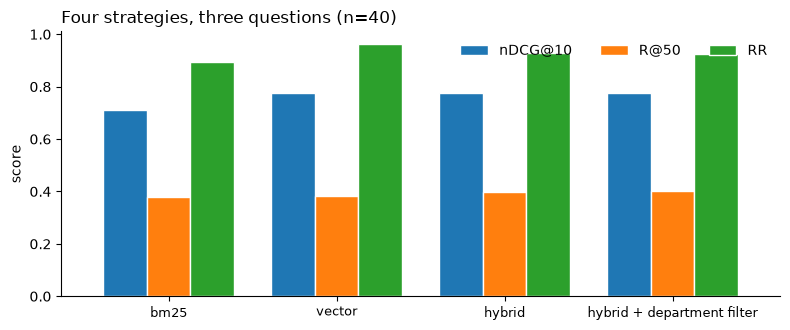

In [13]:
# Chart the four strategies' scores.
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 3.4))
scores.plot.bar(ax=ax, rot=0, width=0.78, edgecolor="white")
ax.set_ylabel("score")
ax.set_xlabel("")
ax.set_title(f"Four strategies, three questions (n={len(evalset.queries)})", loc="left")
ax.legend(frameon=False, ncols=3)
ax.spines[["top", "right"]].set_visible(False)
plt.xticks(ha="center", fontsize=9)
plt.tight_layout()
plt.show()

## Where to take this

- **Make the filter conditional.** Apply it when the classifier is confident and skip it when
  it is not. You have the ingredient already:
  [`enrich/01`](../enrich/01_hypothetical_classification.ipynb) produces a category *with a
  similarity score*, and a weak score is exactly the signal that the filter is a bad bet for
  that query.
- **Retrieve wide, then rerank.** The recall column is the ceiling for anything that runs
  afterwards. A cheap strategy with high R@50 feeding an expensive reranker usually beats an
  expensive strategy used alone — and the table above tells you which strategies have that
  ceiling.
- **Tune the hybrid balance.** This notebook gives the lexical and vector halves whatever
  weighting the Search service defaults to. Real systems tune it, and it is worth measuring
  rather than guessing.
- **Raise `CANDIDATES`.** The vector half considers 200 candidates before the top 50 are cut.
  Raising it costs latency and usually buys recall — measurable in one line here.

> **On Couchbase AI Data Plane** — the embedding step above runs on your machine and the
> vectors are written by hand. The managed service generates and maintains them for you as
> documents change, which is the difference between a demo and something that stays correct
> once the catalogue starts moving. The retrieval half of this notebook — one index carrying
> text, vectors and keyword filters, queried in a single request — is the same either way.

In [14]:
# Optional clean-up: delete what this notebook created. Uncomment to run.
# It lives in the scope `retrieval/01` created, which `03` reuses.
# from cbnb.couchbase_io import drop_demo_data
# drop_demo_data(cluster, BUCKET, SCOPE)